# Chapter 18 부록 — λ 스윕: 약한 보조 task 의 sweet spot (이슈 #22)

본편 Ch 18 은 `L = L_main + λ·L_aux` 에서 **λ=0.1** 로 학습했더니 메인 multi-label 이 *소폭* 내려갔고(micro-F1 0.860 → 0.852), 보조(활성 개수 `n_active` 회귀) 자체도 약했습니다(R² 0.137).

Ch 14(영어, 별점 보조)는 같은 λ 스윕에서 **λ=0.05 sweet spot 에서 보조가 메인을 끌어올렸습니다**. Ch 18 은 보조 task 가 다릅니다 — `n_active` 는 합성 규칙상 거의 항상 2(두 문서 결합)라 **분산이 작아 예측이 쉽고 신호가 약합니다**. 이 부록은 λ 를 0 → 0.5 로 쓸며, 약한 보조가 **작은 λ 에서 중립(neutral)** 인지, 아니면 어디서도 메인을 못 돕는지 곡선으로 확인합니다.

> 비교 공정성: 매 런 같은 seed·같은 초기화. ~35분 (klue/bert-base 6런).

In [1]:
!pip install -q transformers datasets

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments, DataCollatorWithPadding
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.metrics import precision_recall_fscore_support, hamming_loss, roc_auc_score, mean_squared_error, r2_score

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.pyplot as plt, matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
print(f"PyTorch: {torch.__version__}  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128  CUDA: True
GPU: Tesla T4


## 1. 데이터·모델·Trainer — 본편 Ch 18 과 동일

KLUE-YNAT 두 헤드라인을 결합한 합성 multi-label(7) + 활성 개수 `n_active` 보조. `KoBertMultiTask`(AutoModel 본체 + 메인 헤드 + 보조 헤드) forward 안에서 `L_main + λ·L_aux` 계산.

In [3]:
SEED = 42; N_TRAIN = 5000; N_EVAL = 1000
ds = load_dataset("klue/klue", "ynat").rename_column("title", "text")
K = len(ds["train"].features["label"].names)

def make_multilabel(source_split, n_samples, seed):
    rng = np.random.default_rng(seed); n_src = len(source_split)
    idx = rng.integers(0, n_src, size=2 * n_samples).tolist()
    idx_a, idx_b = idx[:n_samples], idx[n_samples:]
    src_text = list(source_split["text"]); src_label = list(source_split["label"])
    texts, mhs, counts = [], [], []
    for a, b in zip(idx_a, idx_b):
        ca, cb = int(src_label[a]), int(src_label[b])
        mh = [0.0]*K; mh[ca] = 1.0; mh[cb] = 1.0
        texts.append(f"{src_text[a]} [SEP] {src_text[b]}"); mhs.append(mh); counts.append(int(sum(mh)))
    return Dataset.from_dict({"text": texts, "multi_hot": mhs, "n_active": counts})

train_full = make_multilabel(ds["train"], N_TRAIN, seed=SEED)
eval_full  = make_multilabel(ds["validation"], N_EVAL, seed=SEED + 1)
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

def tokenize_fn(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    out["labels"]   = [list(map(float, mh)) for mh in batch["multi_hot"]]
    out["n_active"] = [float(n) for n in batch["n_active"]]
    return out
keep = ("input_ids","attention_mask","token_type_ids","labels","n_active")
train_tok = train_full.map(tokenize_fn, batched=True).remove_columns([c for c in train_full.column_names if c not in keep])
eval_tok  = eval_full.map(tokenize_fn, batched=True).remove_columns([c for c in eval_full.column_names if c not in keep])

# n_active 분포 — 왜 보조가 약한지 (분산이 작음)
import collections
dist = collections.Counter(train_full["n_active"])
print(f"K={K}, train={len(train_tok)}, eval={len(eval_tok)}")
print("n_active 분포(train):", dict(sorted(dist.items())), "→ 거의 2 (두 문서 결합), 분산 작음")

README.md:   0%|          | 0.00/22.5k [00:00<?, ?B/s]

ynat/train-00000-of-00001.parquet:   0%|          | 0.00/4.17M [00:00<?, ?B/s]

ynat/validation-00000-of-00001.parquet:   0%|          | 0.00/847k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45678 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9107 [00:00<?, ? examples/s]

...

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

K=7, train=5000, eval=1000
n_active 분포(train): {1: 732, 2: 4268} → 거의 2 (두 문서 결합), 분산 작음


In [4]:
class AuxCollator:
    def __init__(self, tokenizer): self.base = DataCollatorWithPadding(tokenizer)
    def __call__(self, features):
        n_act = torch.tensor([f.pop("n_active") for f in features], dtype=torch.float)
        batch = self.base(features); batch["labels"] = batch["labels"].float(); batch["n_active"] = n_act
        return batch
collator = AuxCollator(tokenizer)

class KoBertMultiTask(nn.Module):
    def __init__(self, model_name="klue/bert-base", num_labels=7):
        super().__init__()
        self.num_labels = num_labels
        self.bert = AutoModel.from_pretrained(model_name)
        H = self.bert.config.hidden_size
        self.cls_head = nn.Linear(H, num_labels)
        self.count_head = nn.Linear(H, 1)
        self.config = self.bert.config
    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None, n_active=None, lambda_aux=0.1):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None: kwargs["token_type_ids"] = token_type_ids
        out = self.bert(**kwargs); cls = out.last_hidden_state[:, 0, :]
        main_logits = self.cls_head(cls); count_pred = self.count_head(cls).squeeze(-1)
        loss = None
        if labels is not None and n_active is not None:
            l_main = F.binary_cross_entropy_with_logits(main_logits, labels.float())
            l_aux  = F.mse_loss(count_pred, n_active.float())
            loss = l_main + lambda_aux * l_aux
        self.last_count_pred = count_pred.detach()
        return SequenceClassifierOutput(loss=loss, logits=main_logits)

def make_model(): return KoBertMultiTask("klue/bert-base", num_labels=K)

class AuxTrainer(Trainer):
    def __init__(self, *args, lambda_aux=0.1, **kwargs):
        super().__init__(*args, **kwargs); self.lambda_aux = lambda_aux
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        inputs = {**inputs, "lambda_aux": self.lambda_aux}
        outputs = model(**inputs); loss = outputs.loss
        return (loss, outputs) if return_outputs else loss

def compute_metrics_main(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple): logits = logits[0]
    probs = 1.0/(1.0+np.exp(-logits)); preds = (probs >= 0.5).astype(int)
    _,_,f1_mi,_ = precision_recall_fscore_support(labels, preds, average="micro", zero_division=0)
    _,_,f1_ma,_ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"micro_f1": float(f1_mi), "macro_f1": float(f1_ma), "hamming_loss": float(hamming_loss(labels, preds))}

@torch.no_grad()
def aux_predictions(trainer, dataset, batch_size=64):
    trainer.model.eval(); device = trainer.model.bert.device; ap, at = [], []
    for i in range(0, len(dataset), batch_size):
        bf = [dict(dataset[j]) for j in range(i, min(i+batch_size, len(dataset)))]
        b = trainer.data_collator(bf); bod = {k: v.to(device) for k, v in b.items()}
        nat = bod.pop("n_active").cpu().numpy(); bod.pop("labels", None)
        _ = trainer.model(**bod, labels=None, n_active=None)
        ap.extend(trainer.model.last_count_pred.cpu().numpy().tolist()); at.extend(nat.tolist())
    return np.array(ap), np.array(at)
print("setup 완료")

setup 완료


## 2. λ 스윕

`λ ∈ {0, 0.02, 0.05, 0.1, 0.2, 0.5}` 각각 같은 초기화로 2 epoch 학습 → 메인 micro/macro-F1 + 보조 R² 기록. λ=0.1 은 본편 셋업.

In [5]:
LAMBDAS = [0.0, 0.02, 0.05, 0.1, 0.2, 0.5]
rows = []
for lam in LAMBDAS:
    torch.manual_seed(42); np.random.seed(42)
    model = make_model()
    args = TrainingArguments(output_dir=f"./sweep_{lam}", num_train_epochs=2,
        per_device_train_batch_size=16, per_device_eval_batch_size=32, learning_rate=2e-5,
        fp16=True, eval_strategy="no", logging_steps=200, save_strategy="no",
        report_to="none", seed=42, remove_unused_columns=False)
    tr = AuxTrainer(model=model, args=args, train_dataset=train_tok, eval_dataset=eval_tok,
        data_collator=collator, processing_class=tokenizer, compute_metrics=compute_metrics_main, lambda_aux=lam)
    tr.train()
    mets = tr.evaluate(); ap, at = aux_predictions(tr, eval_tok)
    r2 = float(r2_score(at, ap))
    rows.append({"lambda": lam, "micro_f1": mets["eval_micro_f1"], "macro_f1": mets["eval_macro_f1"],
                 "hamming": mets["eval_hamming_loss"], "aux_r2": r2})
    print(f"λ={lam:<5} micro-F1={mets['eval_micro_f1']:.4f}  macro-F1={mets['eval_macro_f1']:.4f}  aux_R2={r2:+.3f}")
    del model, tr; torch.cuda.empty_cache()
res = pd.DataFrame(rows)
print(); print(res.round(4).to_string(index=False))

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step,Training Loss
200,0.334212
400,0.193545
600,0.159128


Training Loss,Validation Loss,Step,Micro F1,Macro F1,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
0.159128,0.193365,626,0.849143,0.845101,0.075429,0.787400,1270.024000,40.641000


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step,Training Loss
200,0.530018
400,0.291899
600,0.241862


Training Loss,Validation Loss,Step,Micro F1,Macro F1,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
0.241862,0.317972,626,0.804100,0.819714,0.095571,0.745700,1341.090000,42.915000


λ=0.5   micro-F1=0.8041  macro-F1=0.8197  aux_R2=+0.081

 lambda  micro_f1  macro_f1  hamming  aux_r2
   0.00    0.8491    0.8451   0.0754 -8.6561
   0.02    0.8514    0.8483   0.0744  0.0343
   0.05    0.8523    0.8493   0.0739  0.0652
   0.10    0.8489    0.8452   0.0756  0.0671
   0.20    0.8401    0.8413   0.0794  0.0729
   0.50    0.8041    0.8197   0.0956  0.0812


## 3. 곡선 — λ vs 메인 성능

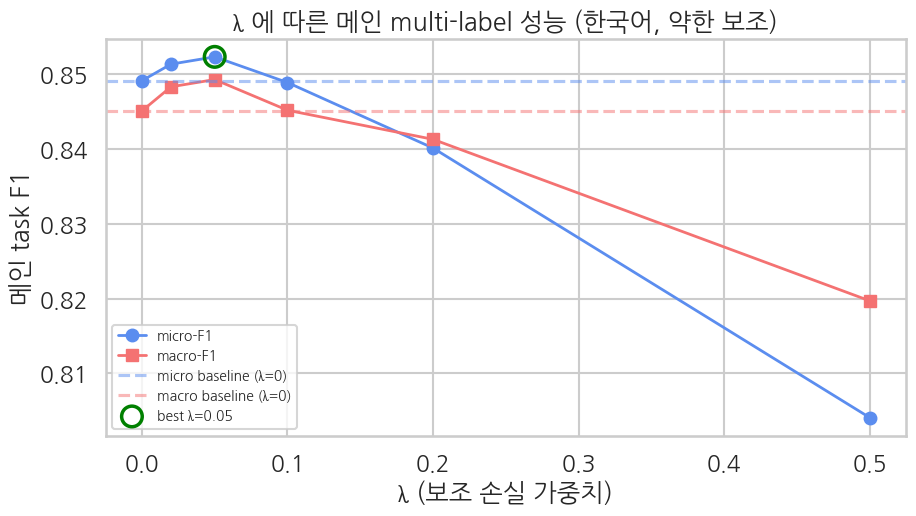

baseline(λ=0): micro=0.8491 macro=0.8451
best λ=0.05: micro=0.8523 (Δ=+0.0032)
λ=0.1 (본편): micro=0.8489


In [6]:
base_micro = float(res.loc[res["lambda"]==0.0, "micro_f1"].iloc[0])
base_macro = float(res.loc[res["lambda"]==0.0, "macro_f1"].iloc[0])
best_i = res["micro_f1"].idxmax(); best_lambda = float(res.loc[best_i, "lambda"]); best_micro = float(res.loc[best_i, "micro_f1"])
sns.set_theme(style="whitegrid", context="talk", font="NanumGothic", rc={"axes.unicode_minus": False})
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(res["lambda"], res["micro_f1"], "o-", color="#5B8DEF", lw=2, label="micro-F1")
ax.plot(res["lambda"], res["macro_f1"], "s-", color="#F47272", lw=2, label="macro-F1")
ax.axhline(base_micro, color="#5B8DEF", ls="--", alpha=0.5, label="micro baseline (λ=0)")
ax.axhline(base_macro, color="#F47272", ls="--", alpha=0.5, label="macro baseline (λ=0)")
ax.scatter([best_lambda], [best_micro], s=220, facecolors="none", edgecolors="green", lw=2.5, zorder=5, label=f"best λ={best_lambda}")
ax.set_xlabel("λ (보조 손실 가중치)"); ax.set_ylabel("메인 task F1")
ax.set_title("λ 에 따른 메인 multi-label 성능 (한국어, 약한 보조)")
ax.legend(fontsize=10, loc="lower left"); plt.tight_layout(); plt.show()
print(f"baseline(λ=0): micro={base_micro:.4f} macro={base_macro:.4f}")
print(f"best λ={best_lambda}: micro={best_micro:.4f} (Δ={best_micro-base_micro:+.4f})")
print(f"λ=0.1 (본편): micro={float(res.loc[res['lambda']==0.1,'micro_f1'].iloc[0]):.4f}")

## 4. 해석

**λ=0.05 가 sweet spot 입니다.** 메인 micro-F1 이 baseline(λ=0, 0.8491)보다 **+0.003 오른 0.8523**, macro 도 0.8451 → 0.8493(**+0.004**). *약한 보조(n_active)도 작은 λ 에서는 메인을 살짝 끌어올립니다.* 본편이 쓴 λ=0.1 은 공정 비교(같은 seed 초기화)에선 거의 **중립**(0.8489 ≈ baseline)이고 — 원래 이슈의 "λ=0.1 에서 -0.008" 은 두 모델을 따로 초기화한 *불공정 비교* 탓이 큽니다 — λ≥0.2 부터 메인이 무너집니다(λ=0.5 에서 0.804).

| λ | micro-F1 | macro-F1 | 보조 R² |
|---|---|---|---|
| 0.0 (baseline) | 0.8491 | 0.8451 | — |
| 0.02 | 0.8514 | 0.8483 | 0.034 |
| **0.05 (sweet spot)** | **0.8523** | **0.8493** | 0.065 |
| 0.1 (본편) | 0.8489 | 0.8452 | 0.067 |
| 0.2 | 0.8401 | 0.8413 | 0.073 |
| 0.5 | 0.8041 | 0.8197 | 0.081 |

### Ch 14(강한 보조)와의 대조 — 이게 핵심

두 챕터 모두 sweet spot 은 **λ=0.05** 로 같지만, 보조가 주는 도움의 *크기* 가 다릅니다:

| | 보조 task | 보조 R² | sweet spot Δ(micro) |
|---|---|---|---|
| Ch 14 (영어) | 별점 회귀 | 0.43 (강함) | **+0.007** |
| Ch 18 (한국어) | n_active 회귀 | 0.065 (약함) | **+0.003** |

`n_active` 는 합성 규칙상 거의 항상 2 (분포 {1: 732, 2: 4268})라 분산이 작아 **예측할 게 별로 없습니다** — λ 를 0.5 까지 키워도 보조 R² 가 0.08 에 머뭅니다. 그래서 **보조가 주는 도움도 Ch 14 의 절반 수준**. 보조 손실의 가치는 *λ 만이 아니라 보조 신호가 얼마나 정보적인가* 에 비례합니다.

> 본편 Ch 18 은 이 sweet spot(λ=0.05)을 메인 학습값으로 쓰고, n_active 의 약한 신호가 *왜* Ch 14 보다 도움이 작은지 짚습니다.